# Data analysis


In [3]:
import json
import os
from collections import Counter

# dataset path
annotation_path = r"C:\Users\User\Downloads\archive\data\annotations.json"

# load json
with open(annotation_path) as f:
    data = json.load(f)

images = data['images']
annotations = data['annotations']
categories = data['categories']

print("Total images:", len(images))
print("Total annotations:", len(annotations))
print("Total categories:", len(categories))

# category id to name
cat_map = {cat['id']: cat['name'] for cat in categories}

# count objects per category
category_count = Counter()

for ann in annotations:
    category_count[cat_map[ann['category_id']]] += 1

print("\nTop 10 categories:")
for cat, count in category_count.most_common(10):
    print(cat, count)

Total images: 1500
Total annotations: 4784
Total categories: 60

Top 10 categories:
Cigarette 667
Unlabeled litter 517
Plastic film 451
Clear plastic bottle 285
Other plastic 273
Other plastic wrapper 260
Drink can 229
Plastic bottle cap 209
Plastic straw 157
Broken glass 138


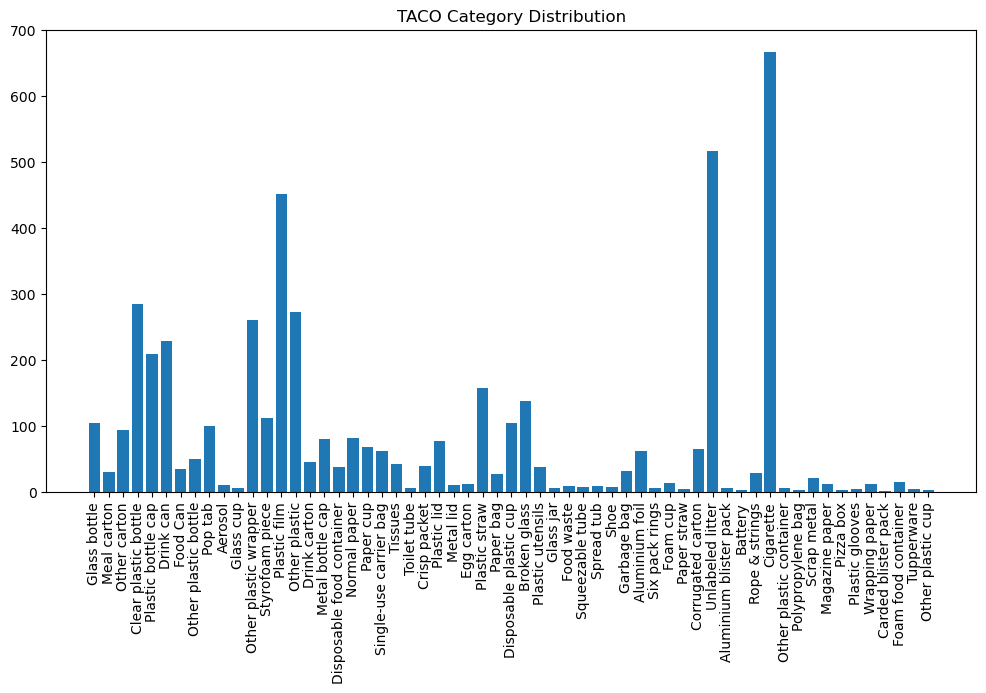

In [3]:
import matplotlib.pyplot as plt

names = list(category_count.keys())
values = list(category_count.values())

plt.figure(figsize=(12,6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("TACO Category Distribution")
plt.show()

In [5]:
from collections import defaultdict

objects_per_image = defaultdict(int)

for ann in annotations:
    objects_per_image[ann['image_id']] += 1

counts = list(objects_per_image.values())

print("Average objects per image:", sum(counts)/len(counts))
print("Max objects in one image:", max(counts))

Average objects per image: 3.1893333333333334
Max objects in one image: 90


In [7]:
import numpy as np

areas = []

for ann in annotations:
    bbox = ann["bbox"]  # [x, y, width, height]
    area = bbox[2] * bbox[3]
    areas.append(area)

print("Average bbox area:", np.mean(areas))
print("Min bbox area:", np.min(areas))
print("Max bbox area:", np.max(areas))

Average bbox area: 263954.6219728457
Min bbox area: 80.0
Max bbox area: 10992160.0


In [9]:
ratios = []

for ann in annotations:
    bbox = ann["bbox"]
    img_id = ann["image_id"]

    img = next(i for i in images if i["id"] == img_id)

    img_area = img["width"] * img["height"]
    bbox_area = bbox[2] * bbox[3]

    ratios.append(bbox_area / img_area)

print("Average object ratio:", sum(ratios)/len(ratios))
print("Min ratio:", min(ratios))
print("Max ratio:", max(ratios))

Average object ratio: 0.02752872481658739
Min ratio: 1.0012174804562347e-05
Max ratio: 0.941941352739726


In [11]:
import numpy as np

widths = []
heights = []
areas = []

for img in images:
    w = img["width"]
    h = img["height"]
    
    widths.append(w)
    heights.append(h)
    areas.append(w*h)

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

print("Min width:", min(widths))
print("Max width:", max(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))

print("Average image area:", np.mean(areas))

Average width: 2824.884
Average height: 3222.825333333333
Min width: 842
Max width: 6000
Min height: 474
Max height: 5312
Average image area: 9091855.188


In [13]:
# show categories with very small number of samples
rare_threshold = 20

rare_classes = {k:v for k,v in category_count.items() if v < rare_threshold}

print("Number of rare classes:", len(rare_classes))
print("\nRare categories (less than 20 samples):")

for k,v in sorted(rare_classes.items(), key=lambda x: x[1]):
    print(k, v)

Number of rare classes: 25

Rare categories (less than 20 samples):
Carded blister pack 1
Battery 2
Other plastic cup 2
Polypropylene bag 3
Pizza box 3
Paper straw 4
Plastic glooves 4
Tupperware 4
Toilet tube 5
Six pack rings 5
Glass cup 6
Glass jar 6
Aluminium blister pack 6
Other plastic container 6
Squeezable tube 7
Shoe 7
Food waste 8
Spread tub 9
Aerosol 10
Metal lid 10
Egg carton 11
Magazine paper 12
Wrapping paper 12
Foam cup 13
Foam food container 15


In [ ]:
import json
import cv2
import random
import os

annotation_path = r"C:\Users\User\Downloads\archive\data\annotations.json"
image_root = r"C:\Users\User\Downloads\archive\data"

# load annotations
with open(annotation_path) as f:
    data = json.load(f)

images = data["images"]
annotations = data["annotations"]
categories = {c["id"]: c["name"] for c in data["categories"]}

# group annotations by image
ann_by_image = {}
for ann in annotations:
    ann_by_image.setdefault(ann["image_id"], []).append(ann)

# choose random images
sample_images = random.sample(images, 5)

for img_info in sample_images:

    img_path = os.path.join(image_root, img_info["file_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    anns = ann_by_image.get(img_info["id"], [])

    for ann in anns:
        x, y, w, h = ann["bbox"]
        cat = categories[ann["category_id"]]

        pt1 = (int(x), int(y))
        pt2 = (int(x+w), int(y+h))

        cv2.rectangle(img, pt1, pt2, (0,255,0), 2)
        cv2.putText(img, cat, (int(x), int(y)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    cv2.imshow("Annotated Image", img)
    cv2.waitKey(0)

cv2.destroyAllWindows()

In [5]:
from collections import defaultdict

# create quick lookup for images
image_lookup = {img["id"]: img for img in images}

# count objects per image
objects_per_image = defaultdict(int)

for ann in annotations:
    objects_per_image[ann["image_id"]] += 1

# sort by number of objects
sorted_images = sorted(objects_per_image.items(), key=lambda x: x[1], reverse=True)

print("Top 10 most crowded images:\n")

for img_id, count in sorted_images[:10]:
    img_info = image_lookup[img_id]
    print(f"{img_info['file_name']} → {count} objects")

Top 10 most crowded images:

batch_6/000072.JPG → 90 objects
batch_8/000021.jpg → 54 objects
batch_12/000061.jpg → 38 objects
batch_12/000062.jpg → 37 objects
batch_13/000025.jpg → 37 objects
batch_2/000048.JPG → 37 objects
batch_6/000066.JPG → 30 objects
batch_15/000029.jpg → 29 objects
batch_8/000065.jpg → 28 objects
batch_12/000025.jpg → 27 objects
